In [ ]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer(as_frame=True)
display(bc.DESCR)

'.. _breast_cancer_dataset:\n\nBreast cancer wisconsin (diagnostic) dataset\n--------------------------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 569\n\n:Number of Attributes: 30 numeric, predictive attributes and the class\n\n:Attribute Information:\n    - radius (mean of distances from center to points on the perimeter)\n    - texture (standard deviation of gray-scale values)\n    - perimeter\n    - area\n    - smoothness (local variation in radius lengths)\n    - compactness (perimeter^2 / area - 1.0)\n    - concavity (severity of concave portions of the contour)\n    - concave points (number of concave portions of the contour)\n    - symmetry\n    - fractal dimension ("coastline approximation" - 1)\n\n    The mean, standard error, and "worst" or largest (mean of the three\n    worst/largest values) of these features were computed for each image,\n    resulting in 30 features.  For instance, field 0 is Mean Radius, field\n    10 is Radius SE, field 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.DataFrame(data=bc.data, columns=bc.feature_names)
df['target'] = bc.target
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df = df.drop(columns=['target'])
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
display(df_scaled.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


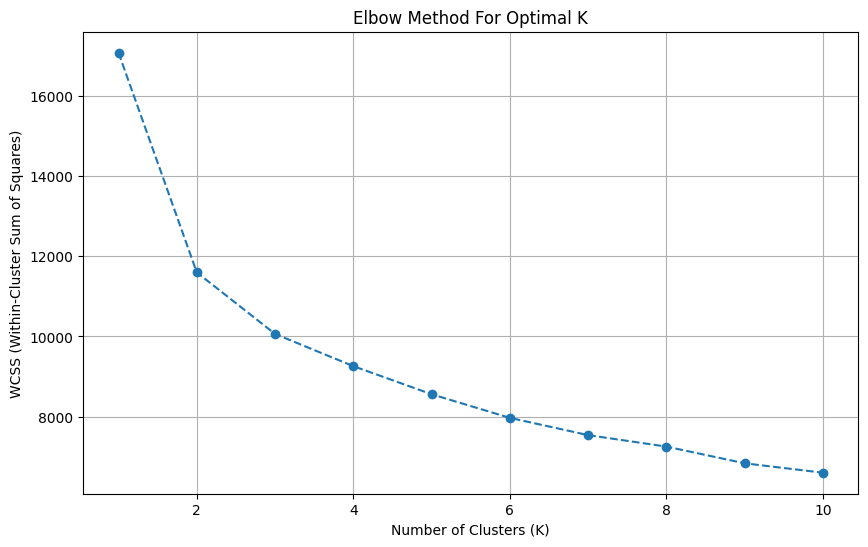

In [ ]:
from sklearn.cluster import KMeans

# Calculate WCSS for different number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

Based on the elbow method, the optimal number of clusters (K) is typically where the decrease in WCSS starts to slow down significantly, forming an 'elbow'. Looking at the plot above, a reasonable 'best K' could be **2**.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_values = [2, 3, 4]

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f'Silhouette Score for K={k}: {score:.4f}')

Silhouette Score for K=2: 0.3434
Silhouette Score for K=3: 0.3144
Silhouette Score for K=4: 0.2833


In [ ]:
!pip install fuzzy_c_means

In [ ]:
from fcmeans import FCM

print('Applying Fuzzy C-means for K=2:')
fcm_k2 = FCM(n_clusters=2, random_state=42)
fcm_k2.fit(df_scaled.to_numpy()) # FCM expects numpy array

print('Cluster Centers for K=2:')
display(pd.DataFrame(fcm_k2.centers, columns=df.columns))

print('\nApplying Fuzzy C-means for K=3:')
fcm_k3 = FCM(n_clusters=3, random_state=42)
fcm_k3.fit(df_scaled.to_numpy())

print('Cluster Centers for K=3:')
display(pd.DataFrame(fcm_k3.centers, columns=df.columns))

Applying Fuzzy C-means for K=2:
Cluster Centers for K=2:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.434796,-0.257785,-0.450351,-0.427311,-0.291538,-0.482833,-0.516339,-0.531391,-0.281401,-0.144929,...,-0.461676,-0.255770,-0.474958,-0.441990,-0.285754,-0.443291,-0.481820,-0.526643,-0.254656,-0.306195
1,0.786729,0.403715,0.809682,0.769986,0.472705,0.782680,0.867607,0.919241,0.452114,0.157388,...,0.838569,0.418627,0.853826,0.802384,0.486233,0.722675,0.795628,0.899357,0.432712,0.457304



Applying Fuzzy C-means for K=3:
Cluster Centers for K=3:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.410805,-0.279706,-0.431471,-0.407330,-0.381136,-0.547570,-0.549332,-0.558492,-0.340128,-0.232951,...,-0.442703,-0.274191,-0.461862,-0.426740,-0.363416,-0.491987,-0.522867,-0.564155,-0.281475,-0.373453
1,-0.267417,-0.075189,-0.264067,-0.271137,0.032085,-0.082338,-0.177953,-0.208456,-0.020054,0.121767,...,-0.276260,-0.072509,-0.267913,-0.276769,0.020113,-0.072614,-0.117766,-0.156513,-0.049045,0.032836
2,1.089077,0.500428,1.111675,1.083738,0.529605,0.931641,1.092834,1.189135,0.517828,0.083321,...,1.158605,0.506358,1.165470,1.133120,0.535476,0.826918,0.951199,1.111448,0.483559,0.452624


In [ ]:
from sklearn.metrics import silhouette_score
import numpy as np

# Get cluster labels from Fuzzy C-means membership matrix
fcm_k2_labels = np.argmax(fcm_k2.u, axis=1)
fcm_k3_labels = np.argmax(fcm_k3.u, axis=1)

# Calculate and print Silhouette Score for K=2
silhouette_fcm_k2 = silhouette_score(df_scaled, fcm_k2_labels)
print(f'Fuzzy C-means Silhouette Score for K=2: {silhouette_fcm_k2:.4f}')

# Calculate and print Silhouette Score for K=3
silhouette_fcm_k3 = silhouette_score(df_scaled, fcm_k3_labels)
print(f'Fuzzy C-means Silhouette Score for K=3: {silhouette_fcm_k3:.4f}')

Fuzzy C-means Silhouette Score for K=2: 0.3400
Fuzzy C-means Silhouette Score for K=3: 0.1607


In [ ]:
from sklearn.mixture import GaussianMixture

print('\nApplying Gaussian Mixture Model for K=2:')
gmm_k2 = GaussianMixture(n_components=2, random_state=42)
gmm_k2.fit(df_scaled)
gmm_k2_labels = gmm_k2.predict(df_scaled)

silhouette_gmm_k2 = silhouette_score(df_scaled, gmm_k2_labels)
print(f'GMM Silhouette Score for K=2: {silhouette_gmm_k2:.4f}')

print('\nApplying Gaussian Mixture Model for K=3:')
gmm_k3 = GaussianMixture(n_components=3, random_state=42)
gmm_k3.fit(df_scaled)
gmm_k3_labels = gmm_k3.predict(df_scaled)

silhouette_gmm_k3 = silhouette_score(df_scaled, gmm_k3_labels)
print(f'GMM Silhouette Score for K=3: {silhouette_gmm_k3:.4f}')


Applying Gaussian Mixture Model for K=2:
GMM Silhouette Score for K=2: 0.3145

Applying Gaussian Mixture Model for K=3:
GMM Silhouette Score for K=3: 0.2515


In [ ]:
from sklearn.cluster import AgglomerativeClustering

print('\nApplying Hierarchical Clustering for K=2:')
hierarchical_k2 = AgglomerativeClustering(n_clusters=2)
hierarchical_k2_labels = hierarchical_k2.fit_predict(df_scaled)

silhouette_hierarchical_k2 = silhouette_score(df_scaled, hierarchical_k2_labels)
print(f'Hierarchical Clustering Silhouette Score for K=2: {silhouette_hierarchical_k2:.4f}')

print('\nApplying Hierarchical Clustering for K=3:')
hierarchical_k3 = AgglomerativeClustering(n_clusters=3)
hierarchical_k3_labels = hierarchical_k3.fit_predict(df_scaled)

silhouette_hierarchical_k3 = silhouette_score(df_scaled, hierarchical_k3_labels)
print(f'Hierarchical Clustering Silhouette Score for K=3: {silhouette_hierarchical_k3:.4f}')


Applying Hierarchical Clustering for K=2:
Hierarchical Clustering Silhouette Score for K=2: 0.3394

Applying Hierarchical Clustering for K=3:
Hierarchical Clustering Silhouette Score for K=3: 0.3301


In [ ]:
data = {
    'Model': ['K-Means', 'K-Means', 'Fuzzy C-means', 'Fuzzy C-means', 'GMM', 'GMM', 'Hierarchical', 'Hierarchical'],
    'K Value': [2, 3, 2, 3, 2, 3, 2, 3],
    'Silhouette Score': [
        silhouette_scores[0], # K-Means K=2
        silhouette_scores[1], # K-Means K=3
        silhouette_fcm_k2,
        silhouette_fcm_k3,
        silhouette_gmm_k2,
        silhouette_gmm_k3,
        silhouette_hierarchical_k2,
        silhouette_hierarchical_k3
    ]
}

silhouette_df = pd.DataFrame(data)
display(silhouette_df)

,Model,K Value,Silhouette Score
0,K-Means,2,0.343382
1,K-Means,3,0.314384
2,Fuzzy C-means,2,0.339971
3,Fuzzy C-means,3,0.160741
4,GMM,2,0.314489
5,GMM,3,0.251499
6,Hierarchical,2,0.339385
7,Hierarchical,3,0.330097


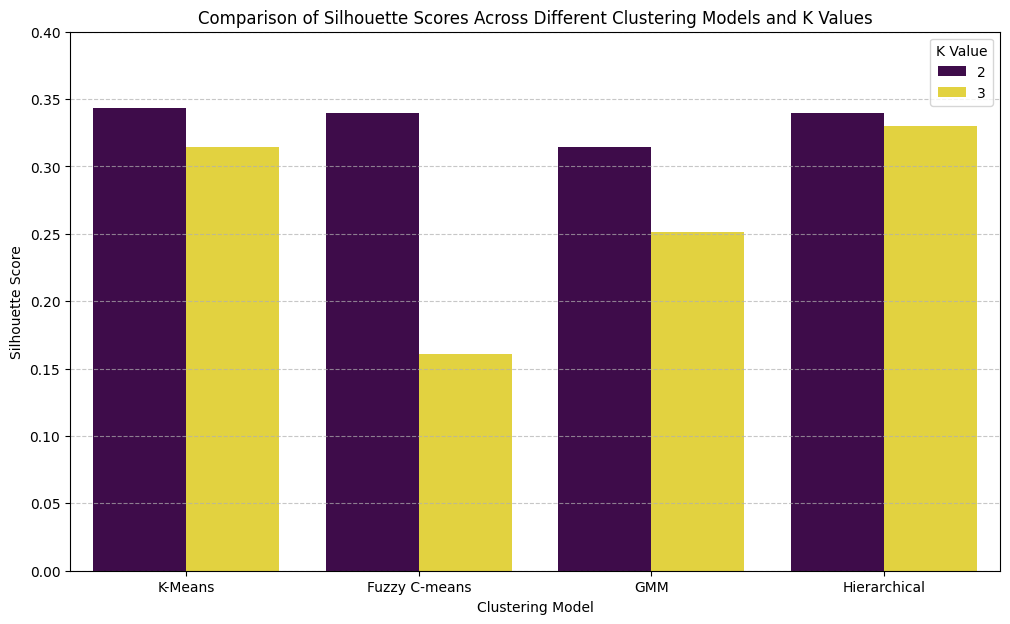

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Silhouette Score', hue='K Value', data=silhouette_df, palette='viridis')
plt.title('Comparison of Silhouette Scores Across Different Clustering Models and K Values')
plt.xlabel('Clustering Model')
plt.ylabel('Silhouette Score')
plt.ylim(0, 0.4) # Set consistent y-axis for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()